# Testing

Performed testing of the image using cosine similarity to check whether the person is authenticated or not.

In [1]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from pathlib import Path


Hyperparameters and directories

In [6]:

TUNING_CONFIG = {
 
    "embeddings_db_path": Path(r"C:\Users\singh\Users\singh\Desktop\Palm detection\ROI\05_palm_embeddings latest work.pkl"),
    "test_image_path": Path(r"C:\Users\singh\Users\singh\Desktop\nnnn\nnnnnn\pandey\p.jpeg"),
    
    # MediaPipe Detection
    "mp_min_detection_confidence": 0.3,  
    
    # ROI Extraction Geometry
    "roi_size_multiplier": 1.1,         
    "roi_center_shift": 0.5,            
    "target_resolution": (224, 224),    
    
    # Preprocessing Pipeline Tuning Metrics
    "clahe_clip_limit": 7.0,            
    "clahe_grid_size": (5, 5),          
    "median_blur_kernel": 3,            
    
    # MFRAT Parameters
    "num_directions": 12,       
    "block_size": 21,           
    "mfrat_threshold_factor": 1.5,
    
    # Security System Bounds 
    "cosine_threshold": 0.65            # Minimum similarity score required to verify user
}

Initializing engines

In [7]:

# 2. Initialize artifacts and engines
if not TUNING_CONFIG["embeddings_db_path"].exists():
    raise FileNotFoundError(f"Embeddings database not found at {TUNING_CONFIG['embeddings_db_path']}. Build Step 7 first!")

# Load the saved database dictionary package
db_package = joblib.load(str(TUNING_CONFIG["embeddings_db_path"]))
db_embeddings = db_package["embeddings"]
db_labels = np.array(db_package["labels"])
db_handedness = np.array(db_package["handedness"])
db_filepaths = np.array(db_package["filepaths"])

# Initialize Landmark Trackers
mp_hands = mp.solutions.hands
detector = mp_hands.Hands(
    static_image_mode=True, 
    max_num_hands=1, 
    min_detection_confidence=TUNING_CONFIG["mp_min_detection_confidence"]
)

# Initialize Deep Feature Extractor
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=pooling_layer)


Pipeline for extract complete ROI from the images for authentication based on principle palm lines.

In [8]:
# 3. Pipeline for authentication

def run_complete_preprocessing_pipeline(img):
    """
    Executes the exact sequential feature engineering pipeline on the test image:
    ROI -> Grayscale -> CLAHE -> Blur -> Min-Max Normalization -> MFRAT
    """
    h, w, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.process(img_rgb)
    
    # PIPELINE SUB-STEP A: ROI Extraction (With Center Fallback)
    if not results.multi_hand_landmarks: 
        crop_size = min(h, w) // 2
        start_x = (w - crop_size) // 2
        start_y = (h - crop_size) // 2
        fallback_roi = img[start_y:start_y+crop_size, start_x:start_x+crop_size]
        roi_color = cv2.resize(fallback_roi, TUNING_CONFIG["target_resolution"])
        hand_label = "Unverified"
    else:
        lm = results.multi_hand_landmarks[0].landmark
        def get_pt(idx): return np.array([lm[idx].x * w, lm[idx].y * h], dtype="float32")

        p0, p5, p9, p17 = get_pt(0), get_pt(5), get_pt(9), get_pt(17)
        hand_label = "Right" if (p5[0]-p0[0])*(p17[1]-p0[1]) - (p5[1]-p0[1])*(p17[0]-p0[0]) > 0 else "Left"

        v_vertical = p9 - p0
        v_vertical_unit = v_vertical / np.linalg.norm(v_vertical)
        angle = np.arctan2(v_vertical_unit[1], v_vertical_unit[0]) - np.pi/2
        v_horizontal_unit = np.array([-v_vertical_unit[1], v_vertical_unit[0]], dtype="float32")
        
        palm_width = np.linalg.norm(p17 - p5)
        roi_center = p9 - (v_vertical_unit * (palm_width * TUNING_CONFIG["roi_center_shift"]))
        half_size = (palm_width * TUNING_CONFIG["roi_size_multiplier"]) / 2.0
        
        local_top_left     = roi_center - (v_horizontal_unit * half_size) + (v_vertical_unit * half_size)
        local_top_right    = roi_center + (v_horizontal_unit * half_size) + (v_vertical_unit * half_size)
        local_bottom_right = roi_center + (v_horizontal_unit * half_size) - (v_vertical_unit * half_size)
        local_bottom_left  = roi_center - (v_horizontal_unit * half_size) - (v_vertical_unit * half_size)
        
        src_pts = np.array([local_top_left, local_top_right, local_bottom_right, local_bottom_left], dtype="float32")
        target_w, target_h = TUNING_CONFIG["target_resolution"]
        dst_pts = np.array([[0, 0], [target_w, 0], [target_w, target_h], [0, target_h]], dtype="float32")

        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillConvexPoly(mask, src_pts.astype(int), 255)
        img_no_bg = cv2.bitwise_and(img, img, mask=mask)
        
        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        roi_color = cv2.warpPerspective(img_no_bg, M, TUNING_CONFIG["target_resolution"])

    # PIPELINE SUB-STEP B: Grayscale Conversion
    roi_gray = cv2.cvtColor(roi_color, cv2.COLOR_BGR2GRAY)

    # PIPELINE SUB-STEP C: CLAHE Contrast Equalization 
    clahe = cv2.createCLAHE(
        clipLimit=TUNING_CONFIG["clahe_clip_limit"], 
        tileGridSize=TUNING_CONFIG["clahe_grid_size"]
    ).apply(roi_gray)

    # PIPELINE SUB-STEP D: Median Blur Smoothing
    blurred = cv2.medianBlur(clahe, TUNING_CONFIG["median_blur_kernel"])

    # PIPELINE SUB-STEP E: Min-Max Intensity Normalization
    normalized = cv2.normalize(blurred, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # PIPELINE SUB-STEP F: Authentic Valley-Isolation MFRAT 
    img_f = normalized.astype(np.float32)
    b_size = TUNING_CONFIG["block_size"]
    center = b_size // 2
    y_idx, x_idx = np.indices((b_size, b_size))
    x_idx, y_idx = x_idx - center, y_idx - center
    
    mfrat_energy_stack = np.zeros((target_h, target_w, TUNING_CONFIG["num_directions"]), dtype=np.float32)
    local_mean = cv2.boxFilter(img_f, -1, (b_size, b_size), borderType=cv2.BORDER_REFLECT)
    
    for d in range(TUNING_CONFIG["num_directions"]):
        theta = (d * np.pi) / TUNING_CONFIG["num_directions"]
        mask = np.abs(x_idx * np.cos(theta) + y_idx * np.sin(theta)) < 0.8
        line_sum = cv2.filter2D(img_f, -1, mask.astype(np.float32), borderType=cv2.BORDER_REFLECT)
        mfrat_energy_stack[:, :, d] = local_mean - (line_sum / np.sum(mask))

    final_energy = np.max(mfrat_energy_stack, axis=-1)
    final_energy[final_energy < (np.mean(final_energy) * TUNING_CONFIG["mfrat_threshold_factor"])] = 0
    mfrat_final = cv2.normalize(cv2.GaussianBlur(final_energy, (5, 5), 0), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return mfrat_final, hand_label

Authentication using cosine similarity

Hand Orientation Filter Active: Matching input [Left] hand strictly against [Left] database templates.


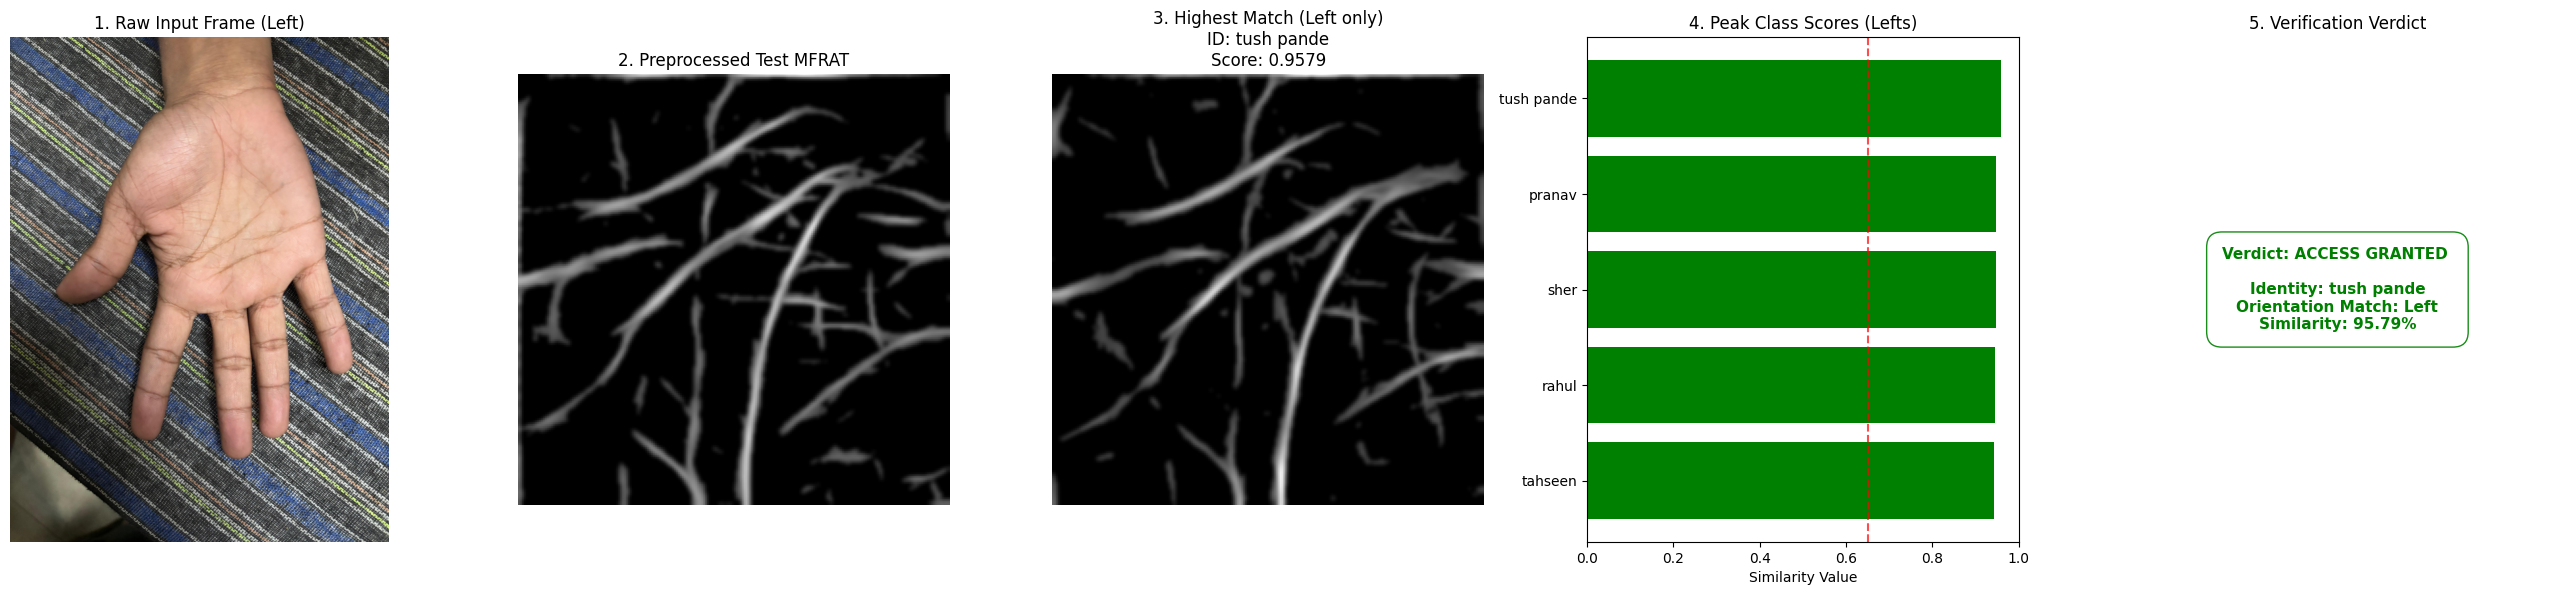


IDENTITY AUTHENTICATION MONITOR LOG (FILTERED BY LEFT HAND)
Target File Verified: final_aug_3_IMG_5837.png
Predicted Class Match: tush pande | Peak Score: 0.9579
RANK  | CLASS NAME           | COSINE SIMILARITY
------------------------------------------------------------
1     | tush pande           | 0.9579
2     | pranav               | 0.9475
3     | sher                 | 0.9471
4     | rahul                | 0.9446
5     | tahseen              | 0.9428


In [10]:
# 4. Authentication using cosine similarity
def test_authentication():
    test_path = TUNING_CONFIG["test_image_path"]
    raw_img = cv2.imread(str(test_path))
    if raw_img is None: return print(f"Test image not found at target path: {test_path}")

    # Process input image through the pipeline modules
    preprocessed_test_mfrat, hand_label = run_complete_preprocessing_pipeline(raw_img)

    # Extract embedding vector profile
    img_3ch = cv2.cvtColor(preprocessed_test_mfrat, cv2.COLOR_GRAY2RGB)
    img_batch = preprocess_input(np.expand_dims(img_3ch, axis=0).astype(np.float32))
    test_embedding = feature_extractor.predict(img_batch, verbose=0)[0]
    test_embedding /= np.linalg.norm(test_embedding)

    
    # Hand-label embedding filter 
    
    # If hand detection was successful, limit search criteria strictly to matching handedness labels
    if hand_label in ["Left", "Right"]:
        print(f"Hand Orientation Filter Active: Matching input [{hand_label}] hand strictly against [{hand_label}] database templates.")
        hand_mask = (db_handedness == hand_label)
        
        # Check if matching configurations exist in database
        if not np.any(hand_mask):
            return print(f"Aborting verification: No registered '{hand_label}' hands exist in the saved embedding file.")
            
        filtered_embeddings = db_embeddings[hand_mask]
        filtered_labels = db_labels[hand_mask]
        filtered_filepaths = db_filepaths[hand_mask]
    else:
        # Fallback security profile context (processes everything if MediaPipe returned 'Unverified')
        print("Hand tracking unverified. Executing fallback match across all templates...")
        filtered_embeddings = db_embeddings
        filtered_labels = db_labels
        filtered_filepaths = db_filepaths

    # Compute Cosine Similarity strictly across the filtered hand records
    cosine_similarities = np.dot(filtered_embeddings, test_embedding)
    
    # Isolate absolute single highest individual instance match in the filtered database subset
    best_match_idx = np.argmax(cosine_similarities)
    highest_similarity_score = cosine_similarities[best_match_idx]
    best_match_file_path = filtered_filepaths[best_match_idx]
    predicted_user_class = filtered_labels[best_match_idx]

    # Calculate peak similarities across the unique user classes inside the filtered slice
    unique_classes = np.unique(filtered_labels)
    class_average_similarities = {}
    for c in unique_classes:
        class_mask = (filtered_labels == c)
        class_average_similarities[c] = np.max(cosine_similarities[class_mask])

    sorted_class_scores = sorted(class_average_similarities.items(), key=lambda x: x[1], reverse=True)

    # Validate security threshold matching rules
    if highest_similarity_score >= TUNING_CONFIG["cosine_threshold"]:
        auth_status = "ACCESS GRANTED "
        decision_color = "green"
        display_user = predicted_user_class
    else:
        auth_status = "ACCESS DENIED \n(Low Similarity)"
        decision_color = "red"
        display_user = "Unknown User"

    # Load the highest scoring template file from storage disk
    matched_gallery_img = cv2.imread(best_match_file_path, cv2.IMREAD_GRAYSCALE)

   
    # 5. Dataset panel rendering (5 window panels)
    
    fig = plt.figure(figsize=(26, 6))
    gs = fig.add_gridspec(1, 5)

    # Panel 1: Original input reference frame
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    ax0.set_title(f"1. Raw Input Frame ({hand_label})")
    ax0.axis('off')
    
    # Panel 2: Current pipeline processed test image
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(preprocessed_test_mfrat, cmap='gray')
    ax1.set_title("2. Preprocessed Test MFRAT")
    ax1.axis('off')
    
    # Panel 3: Absolute maximum matched file located within template base
    ax2 = fig.add_subplot(gs[0, 2])
    if matched_gallery_img is not None:
        ax2.imshow(matched_gallery_img, cmap='gray')
        ax2.set_title(f"3. Highest Match ({hand_label} only)\nID: {predicted_user_class}\nScore: {highest_similarity_score:.4f}")
    else:
        ax2.text(0.5, 0.5, "Image Link Broken", ha='center', va='center')
    ax2.axis('off')
    
    # Panel 4: System similarity distribution map against other identity registers
    ax3 = fig.add_subplot(gs[0, 3])
    top_n_classes = min(5, len(sorted_class_scores))
    display_names = [x[0] for x in sorted_class_scores[:top_n_classes]][::-1]
    display_scores = [x[1] for x in sorted_class_scores[:top_n_classes]][::-1]
    
    bar_colors = ['green' if s >= TUNING_CONFIG["cosine_threshold"] else 'gray' for s in display_scores]
    ax3.barh(display_names, display_scores, color=bar_colors)
    ax3.axvline(TUNING_CONFIG["cosine_threshold"], color='red', linestyle='--', alpha=0.7, label='Security Line')
    ax3.set_xlim(0, 1.0)
    ax3.set_title(f"4. Peak Class Scores ({hand_label}s)")
    ax3.set_xlabel("Similarity Value")
    
    # Panel 5: Authorization System Status
    ax4 = fig.add_subplot(gs[0, 4])
    verdict_box_text = f"Verdict: {auth_status}\n\nIdentity: {display_user}\nOrientation Match: {hand_label}\nSimilarity: {highest_similarity_score * 100:.2f}%"
    ax4.text(0.5, 0.5, verdict_box_text, fontsize=11, ha='center', va='center', weight='bold', 
                 color=decision_color, bbox=dict(facecolor='white', alpha=0.9, edgecolor=decision_color, boxstyle='round,pad=1'))
    ax4.set_title("5. Verification Verdict")
    ax4.axis('off')
    
    plt.tight_layout()
    plt.show()

    # Terminal Analytics Logging
    print("\n" + "="*60)
    print(f"IDENTITY AUTHENTICATION MONITOR LOG (FILTERED BY {hand_label.upper()} HAND)")
    print(f"Target File Verified: {Path(best_match_file_path).name}")
    print(f"Predicted Class Match: {predicted_user_class} | Peak Score: {highest_similarity_score:.4f}")
    print("="*60)
    print(f"{'RANK':<5} | {'CLASS NAME':<20} | {'COSINE SIMILARITY'}")
    print("-" * 60)
    for index, (class_name, score) in enumerate(sorted_class_scores[:5]):
        print(f"{index+1:<5} | {class_name:<20} | {score:.4f}")
    print("="*60)

if __name__ == "__main__":
    test_authentication()